<a href="https://colab.research.google.com/github/omprakashravula/Flight_Eda_dashboard_using_sql-and-streamlit/blob/main/cv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [ ]:
img=image.load_img('/content/colorimage1.jpg',target_size=(256,256))

In [ ]:
img_array=image.img_to_array(img)

In [ ]:
img_array=img_array/255.0
img_tensor=np.expand_dims(img_array,axis=0)

In [ ]:
print(img_tensor.shape)

(1, 256, 256, 3)


In [ ]:
#kernals
vertical=np.array([[-1,0,1],[-2,0,2],[-1,0,1]],dtype=np.float32)
horizontal=np.array([[-1,-2,-2],[0,0,0],[1,2,1]],dtype=np.float32)
sharpen=np.array([[0,-1,0],[-1,5,-1],[0,-1,0]],dtype=np.float32)
blur=np.array([[1,1,1],[1,1,1],[1,1,1]],dtype=np.float32)

In [ ]:
vertical

array([[-1.,  0.,  1.],
       [-2.,  0.,  2.],
       [-1.,  0.,  1.]], dtype=float32)

In [ ]:
vertical=np.stack([vertical]*3,axis=2)
horizontal=np.stack([horizontal]*3,axis=2)
sharpen=np.stack([sharpen]*3,axis=2)
blur=np.stack([blur]*3,axis=2)

In [ ]:
vertical

array([[[-1., -1., -1.],
        [ 0.,  0.,  0.],
        [ 1.,  1.,  1.]],

       [[-2., -2., -2.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[-1., -1., -1.],
        [ 0.,  0.,  0.],
        [ 1.,  1.,  1.]]], dtype=float32)

In [ ]:
kernels=np.stack([vertical,
                  horizontal,
                  sharpen,
                  blur
                  ],axis=3)

In [ ]:
kernels

array([[[[-1., -1.,  0.,  1.],
         [-1., -1.,  0.,  1.],
         [-1., -1.,  0.,  1.]],

        [[ 0., -2., -1.,  1.],
         [ 0., -2., -1.,  1.],
         [ 0., -2., -1.,  1.]],

        [[ 1., -2.,  0.,  1.],
         [ 1., -2.,  0.,  1.],
         [ 1., -2.,  0.,  1.]]],


       [[[-2.,  0., -1.,  1.],
         [-2.,  0., -1.,  1.],
         [-2.,  0., -1.,  1.]],

        [[ 0.,  0.,  5.,  1.],
         [ 0.,  0.,  5.,  1.],
         [ 0.,  0.,  5.,  1.]],

        [[ 2.,  0., -1.,  1.],
         [ 2.,  0., -1.,  1.],
         [ 2.,  0., -1.,  1.]]],


       [[[-1.,  1.,  0.,  1.],
         [-1.,  1.,  0.,  1.],
         [-1.,  1.,  0.,  1.]],

        [[ 0.,  2., -1.,  1.],
         [ 0.,  2., -1.,  1.],
         [ 0.,  2., -1.,  1.]],

        [[ 1.,  1.,  0.,  1.],
         [ 1.,  1.,  0.,  1.],
         [ 1.,  1.,  0.,  1.]]]], dtype=float32)

In [ ]:
kernels.shape

(3, 3, 3, 4)

In [ ]:
#let us create 2d convolution layers\
conv=tf.keras.layers.Conv2D(filters=4,
                            kernel_size=(3,3),
                            padding='same',
                            use_bias=False)
conv.build(img_tensor.shape)
conv.set_weights([kernels])

In [ ]:
feature_map=conv(img_tensor)

In [ ]:
feature_map=feature_map.numpy()[0]

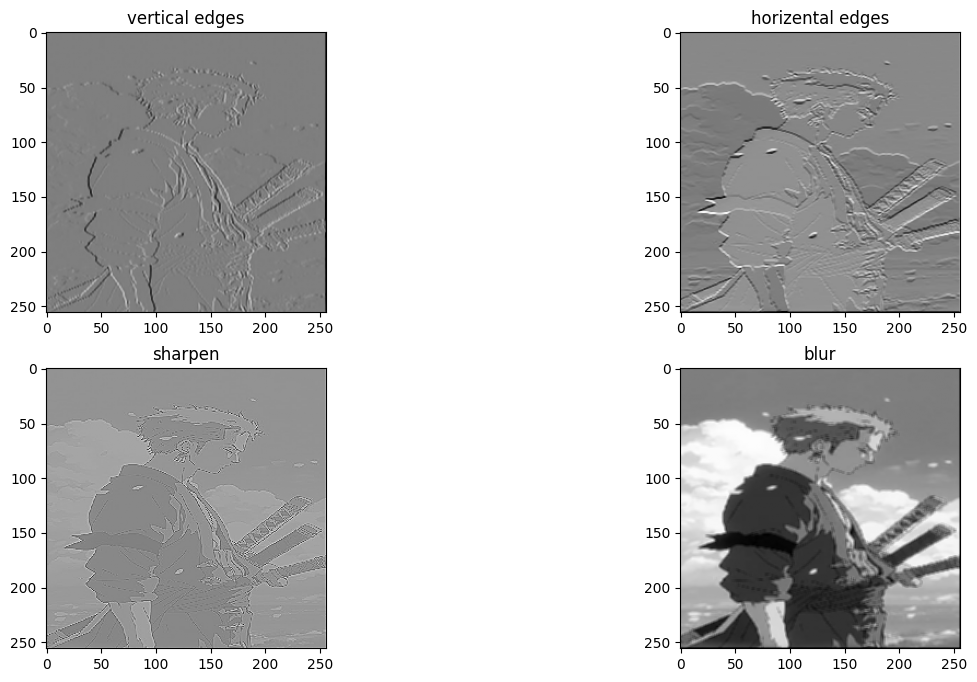

In [ ]:
title=[
    'vertical edges',
    'horizental edges',
    'sharpen',
    'blur'
]
plt.figure(figsize=(15,8))
for i in range(4):
  plt.subplot(2,2,i+1)
  plt.imshow(feature_map[:,:,i],cmap='gray')
  plt.title(title[i])
  plt.axis='off'

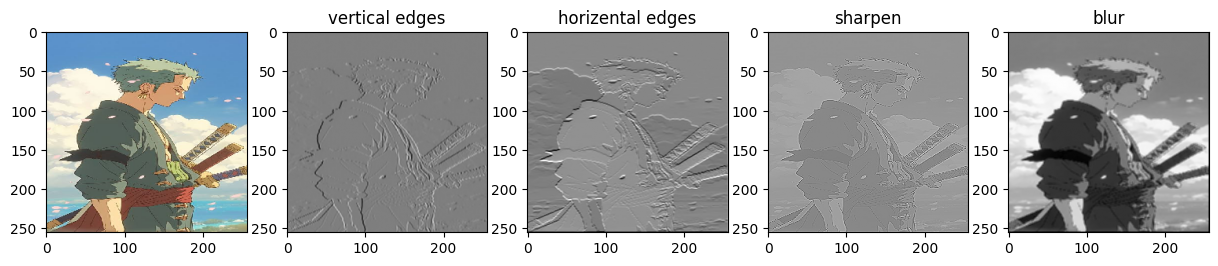

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,5,1)
plt.imshow(img_array)
for i in range(4):
  plt.subplot(1,5,i+2)
  plt.imshow(feature_map[:,:,i],cmap='gray')
  plt.title(title[i])
  plt.axis='off'